# Study 265 -- IPO-Volume
## For the curious: is a flood of IPOs the bell at the top of the market?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

Every cycle the story comes back: the IPO window is wide open, hundreds of
companies are rushing to list, your barber is talking about the latest debut --
*surely* that is the bell ringing at the top. 1999. 2021. The famous floods.

But does a big IPO year actually **predict** a bad year for the market *next*
year? Or does it just **coincide** with the good year we are already having? We
pair the canonical annual US IPO count with the S&P 500's calendar-year return
and let the tape settle it.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_volume import data, strategy as st

SHILLER = os.path.join(data.REPO_CACHE, "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(SHILLER)

if HAVE_REAL:
    df = data.fetch_sp500_annual()
    z = st.froth_signal(df, min_obs=5)
    reg = st.predictive_regression(z, df["fwd_return"])
    tm = st.timing_returns(z, df["fwd_return"], threshold=0.0, one_way_bps=5.0)
    print(f"Real annual tape loaded: {len(df)} forecastable years "
          f"{int(df['year'].min())}-{int(df['year'].max())}")
    print(f"Predictive slope HAC t = {reg['beta_t']:+.2f}")
else:
    df = z = reg = tm = None
    print("No Shiller cache -- frozen headline numbers from R dict will be used")


Real annual tape loaded: 45 forecastable years 1980-2024
Predictive slope HAC t = -0.07


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_years': 41, 'year_start': 1980, 'year_end': 2024, 'fingerprint': 'a6855574f53b', 'beta': -0.0019, 'beta_t': -0.07, 'r2': 0.0, 'pred_corr': -0.011, 'contemp_corr': 0.317, 'sub_a_label': '1985-1999', 'sub_a_beta': -0.007, 'sub_a_t': -0.19, 'sub_a_n': 15, 'sub_b_label': '2000-2012', 'sub_b_beta': -0.159, 'sub_b_t': -2.11, 'sub_b_n': 13, 'sub_c_label': '2013-2024', 'sub_c_beta': -0.207, 'sub_c_t': -6.23, 'sub_c_n': 12, 'strat_mean': 8.33, 'strat_vol': 14.0, 'strat_t': 4.12, 'strat_hit': 0.59, 'bh_mean': 10.79, 'bh_vol': 15.8, 'bh_t': 4.68, 'bh_hit': 0.76, 'excess_mean': -2.46, 'excess_t': -1.12, 'n_long': 29, 'n_switches': 9, 'drag_bps': 45, 'syn_null_beta': -0.004, 'syn_null_t': -0.36, 'syn_froth_beta': -0.056, 'syn_froth_t': -4.92}


## The picture everyone remembers: IPO floods and famous tops

The eye locks onto 1999 (476 IPOs, then the dot-com bust) and 2021 (the SPAC-era
flood, then the 2022 drawdown). What it forgets: the 2008 window slammed shut
(21 IPOs) right before one of the worst years -- and the *rebound* came while the
IPO market was still frozen. The timing is messier than the legend.


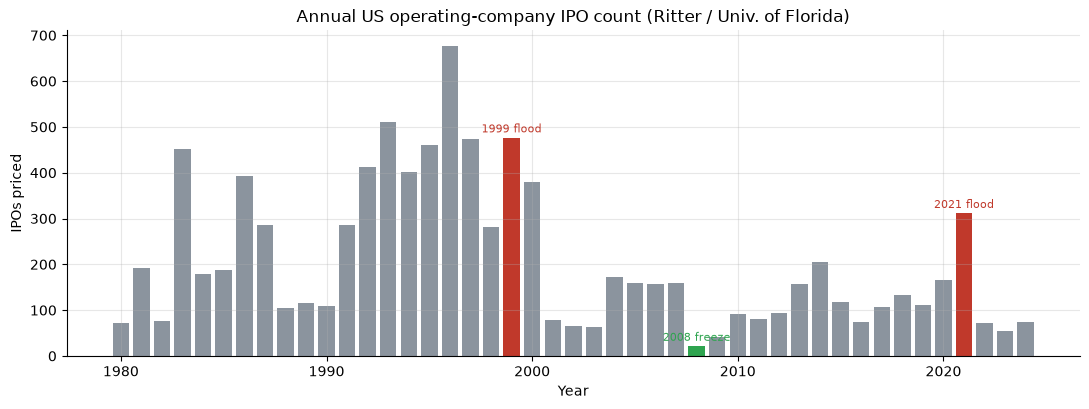

Dot-com flood 1999: 476 IPOs   |   2008 freeze: 21 IPOs


In [3]:
ipo = data.ipo_table().set_index("year")["ipo_count"]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(ipo.index, ipo.values, color=GREY, width=0.8)
for yr, col, txt in [(1999, RED, "1999 flood"), (2008, GREEN, "2008 freeze"), (2021, RED, "2021 flood")]:
    if yr in ipo.index:
        ax.bar([yr], [ipo.loc[yr]], color=col)
        ax.text(yr, ipo.loc[yr] + 12, txt, ha="center", fontsize=8, color=col)
ax.set_title("Annual US operating-company IPO count (Ritter / Univ. of Florida)")
ax.set_ylabel("IPOs priced")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig("../docs/ipo_counts.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Dot-com flood 1999: {int(ipo.loc[1999])} IPOs   |   2008 freeze: {int(ipo.loc[2008])} IPOs")


## The coincidence trap: 'during' is not 'before'

Here is the whole study in one comparison. IPO volume is genuinely high *during*
good years -- a **+0.32** correlation with the *same-year* return. That is what
makes the bell-at-the-top story feel obviously true.

But the only thing a trader can act on is whether a frothy year today predicts a
bad year *tomorrow*. And that correlation is **-0.01** -- a flat zero. The
indicator is *coincident*, not *leading*.


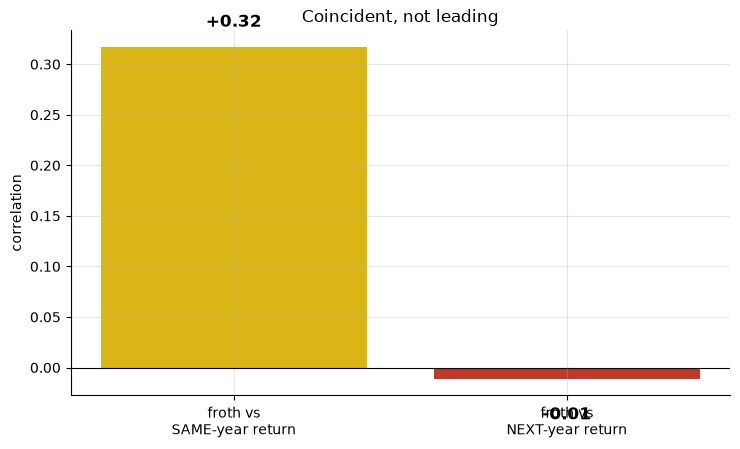

Same-year (contemporaneous) corr: +0.32  -- IPOs flood DURING good years
Next-year (predictive)     corr: -0.01  -- froth tells you nothing about tomorrow


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
if HAVE_REAL:
    pair = pd.concat([z.rename("z"), df["sp500_return"].rename("contemp")], axis=1).dropna()
    contemp = float(np.corrcoef(pair["z"], pair["contemp"])[0, 1])
    pred = reg["corr"]
else:
    contemp, pred = R["contemp_corr"], R["pred_corr"]
bars = ax.bar(["froth vs\nSAME-year return", "froth vs\nNEXT-year return"],
              [contemp, pred], color=[AMBER, RED])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("correlation")
ax.set_title("Coincident, not leading")
for b, v in zip(bars, [contemp, pred]):
    ax.text(b.get_x() + b.get_width()/2, v + (0.02 if v >= 0 else -0.04),
            f"{v:+.2f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Same-year (contemporaneous) corr: {contemp:+.2f}  -- IPOs flood DURING good years")
print(f"Next-year (predictive)     corr: {pred:+.2f}  -- froth tells you nothing about tomorrow")


## Could you trade it? A simple 'sit out the froth' rule

The natural trade: stay long the S&P next year *unless* this year was frothy
(IPO z-score above zero), in which case go to cash. If the bell-at-the-top story
were real, dodging the frothy years should help.

It doesn't. The rule trails plain buy-and-hold by about **2.5%/yr** -- because
"frothy" years are usually *good* years, and you spend the next one in cash for
nothing.


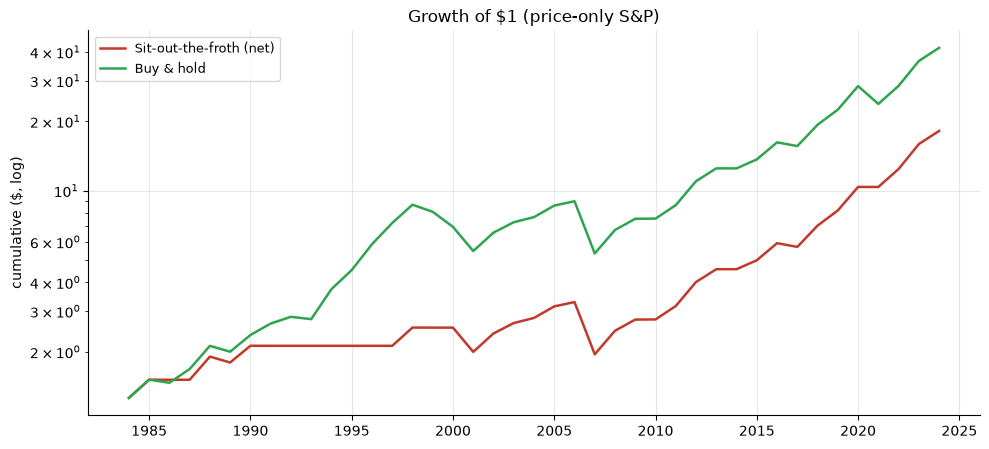

Sit-out-the-froth: +8.33%/yr   Buy & hold: +10.79%/yr
The rule trails buy-and-hold by -2.46%/yr -- dodging froth dodges good years.


In [5]:
if HAVE_REAL:
    s_n = st.summarize(tm["strat_net"]); s_bh = st.summarize(tm["buy_hold"])
    strat_mean, bh_mean = s_n["mean"]*100, s_bh["mean"]*100
    cum_s = (1 + tm["strat_net"]).cumprod()
    cum_b = (1 + tm["buy_hold"]).cumprod()
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.plot(df["year"].iloc[-len(cum_s):], cum_s.values, color=RED, lw=1.8, label="Sit-out-the-froth (net)")
    ax.plot(df["year"].iloc[-len(cum_b):], cum_b.values, color=GREEN, lw=1.8, label="Buy & hold")
    ax.set_yscale("log"); ax.set_title("Growth of $1 (price-only S&P)")
    ax.set_ylabel("cumulative ($, log)"); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight"); plt.show()
else:
    strat_mean, bh_mean = R["strat_mean"], R["bh_mean"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(["Sit-out-the-froth", "Buy & hold"], [strat_mean, bh_mean], color=[RED, GREEN])
    ax.set_ylabel("mean return (%/yr)"); ax.set_title("(frozen numbers)")
    plt.tight_layout(); plt.show()
print(f"Sit-out-the-froth: {strat_mean:+.2f}%/yr   Buy & hold: {bh_mean:+.2f}%/yr")
print(f"The rule trails buy-and-hold by {R['excess_mean']:+.2f}%/yr -- dodging froth dodges good years.")


## The bottom line for the curious

The flood of IPOs **feels** like the bell at the top because it really is loud at
the top -- but it rings *during* the party, not the morning before the hangover.
By the time the market actually rolls over, the IPO window has usually already
closed on its own.

- IPO volume vs **same-year** return: **+0.32** (coincident)
- IPO volume vs **next-year** return: **-0.01** (no forecast power)
- A "sit out the froth" rule loses to buy-and-hold by ~2.5%/yr

This is a **None / Mirage**: a vivid coincidence dressed up as a leading
indicator.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*